In [1]:
import os
import glob
import graphical_sampling as gs
import pandas as pd
import numpy as np
import itertools
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities

/Users/mehdi/Documents/Projects/graphical-sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "XPC_SERVICE_NAME" redefined by R and overriding existing variable. Current: "application.com.jetbrains.pycharm.16718300.16732792", R: "0"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical-sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//Rtmp5so9r2", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpJWBXR5"
  warnings.warn(


In [2]:
N = 1000
n = 10
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
probs = rng.unequal_inclusions(n, N)
modified_probs = inclusion_probabilities(probs, n=n)
pop = gs.Population(coords, modified_probs)

In [18]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())
print(probs_dict.keys())
print(probs_dict['random'].keys())

dict_keys(['swiss', 'RegularPop1000', 'AggregatedPop1027', 'cluster', 'meuse', 'random', 'grid'])
dict_keys(['swiss', 'RegularPop1000', 'AggregatedPop1027', 'cluster', 'meuse', 'random', 'grid'])
dict_keys(['equal', 'unequal'])


In [23]:
N = 100
n = 5
coords = coords_dict['random']
probs = probs_dict['random']['unequal']
probs = inclusion_probabilities(probs, n=n)
pop = gs.Population(coords, probs)

# Clustering

In [3]:
np_rng = np.random.default_rng(seed=42)
inits = np_rng.random((n, 2))

In [6]:
fbn = gs.clustering.FIPBalancedNMeans(n=n)
fbn.fit(pop, init_centroids=inits)

<Axes: title={'center': 'FIP Balanced 10-Means Hard Clustering'}, xlabel='$X_1$', ylabel='$X_2$'>

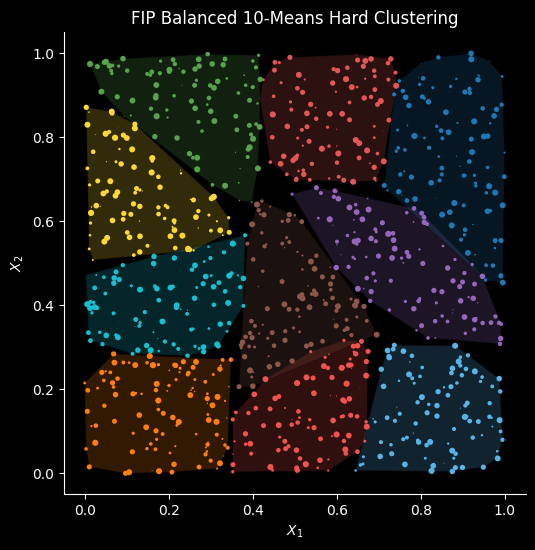

In [7]:
fbn.plot(mode='hard')

In [20]:
sums = np.array([probs[fbn.labels == i].sum() for i in range(n)])
print(sums)

[1.00353642 0.9996253  0.99391569 1.00569084 0.99444874 1.00279104
 1.00729556 0.98731906 1.00774904 0.99762832]


# Density

In [8]:
den = gs.index.DensityDisparity(pop, n)

In [9]:
np_rng = np.random.default_rng()
num_sample = 1000
samples = np_rng.choice(N, size=(num_sample, n), replace=True, p=pop.inclusions / n)

In [10]:
scores = den.score(samples)

/Users/mehdi/Documents/Projects/graphical-sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpJWBXR5", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpfycVgy"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical-sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpJWBXR5", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpKgmcI5"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical-sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders

In [11]:
scores[:20]

array([-0.29075653, -0.59447642, -0.19069926, -0.28460008, -0.13458581,
       -0.13551261, -0.66338611, -0.26790219, -0.73298548, -0.53802965,
       -0.56275373,  0.17010915, -0.46571522, -0.32434463, -0.34477613,
       -0.35357195, -0.35274871, -0.35048629,  0.23880355, -0.41090424])